loaded (9600, 25) (3200, 25)
baseline stump ensemble trained | trees = 300
LOSSLESS assertion PASSED (residual is constant at float32 precision)
[saved] 02_lossless_verification.csv
[saved] 02_quantization_only_loss.csv
[saved] 02_step_functions.png  &  02_step_functions.pdf


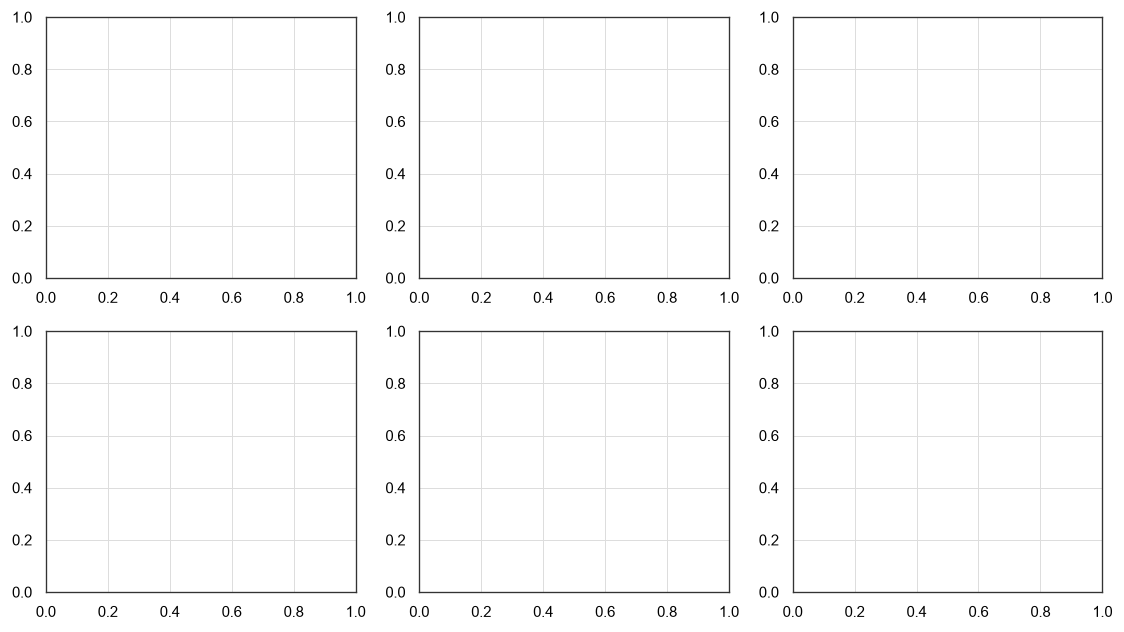

[saved] 02_baseline_scorecard.csv
scorecard rows: 133


,feature,bin,lo,hi,logodds,points
0,EXT_SOURCE_3,0,-inf,0.0747,0.0535,-2.0
1,EXT_SOURCE_3,1,0.0747,0.1710,-0.5275,15.0
2,EXT_SOURCE_3,2,0.1710,0.1793,-0.5554,16.0
3,EXT_SOURCE_3,3,0.1793,0.1958,-0.6300,18.0
4,EXT_SOURCE_3,4,0.1958,0.4023,-0.9414,27.0
5,EXT_SOURCE_3,5,0.4023,0.4040,-1.1012,32.0
6,EXT_SOURCE_3,6,0.4040,0.4750,-1.3265,38.0
7,EXT_SOURCE_3,7,0.4750,0.4876,-1.3870,40.0
8,EXT_SOURCE_3,8,0.4876,0.5665,-1.4685,42.0
9,EXT_SOURCE_3,9,0.5665,0.5963,-1.6738,48.0


In [1]:
# Notebook 02 — Lossless Reduction & the Three Degrees of Freedom (Track A)

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import common as C
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
meta = json.load(open(C.PROC_DIR / "meta.json"))
FEATURES = meta["features"]
Xtr, ytr = X.iloc[SP["train"]], y[SP["train"]]
Xev, yev = X.iloc[SP["eval"]], y[SP["eval"]]
print("loaded", Xtr.shape, Xev.shape)


# ----------------------------------------------------------------------------
# Fit a baseline stump ensemble (hard labels, standard/greedy binning)
#   max_depth=1  ==  Map A prerequisite (no feature interactions)
# ----------------------------------------------------------------------------
dtr = xgb.DMatrix(Xtr, label=ytr, feature_names=FEATURES)
dev = xgb.DMatrix(Xev, label=yev, feature_names=FEATURES)
# exact/CPU stumps => exact lossless reduction (see common.xgb_base_params)
params = C.xgb_base_params(base_score=0.5)
bst = xgb.train(params, dtr, num_boost_round=300)
print("baseline stump ensemble trained | trees =", bst.num_boosted_rounds())


# ----------------------------------------------------------------------------
# Map A: extract the additive scorecard and VERIFY losslessness
# ----------------------------------------------------------------------------
sc = C.extract_scorecard_from_xgb(bst, FEATURES)
margin_xgb = bst.predict(dev, output_margin=True)
margin_sc  = sc.margin(Xev)
resid = margin_xgb - margin_sc

verify = pd.DataFrame([{
    "n_features_used": len(sc.features),
    "n_cells_C": sc.n_cells(),
    "max_abs_residual": float(np.max(np.abs(resid))),
    "std_residual": float(np.std(resid)),
    "AUC_xgb": C.auc(yev, C.sigmoid(margin_xgb)),
    "AUC_scorecard": C.auc(yev, sc.predict_proba(Xev)),
}])
# residual is a *constant* at float32 precision -> re-arrangement is exact
assert verify.loc[0, "std_residual"] < 1e-5, "Map A not lossless!"
print("LOSSLESS assertion PASSED (residual is constant at float32 precision)")
C.save_table(verify.round(8), "02_lossless_verification")
verify.round(8)


# ----------------------------------------------------------------------------
# Quantization is the ONLY loss: continuous vs integer scorecard
# ----------------------------------------------------------------------------
sc.quantize(pdo=20, grid=1, base_points=600)
p_cont = sc.predict_proba(Xev)
p_quant = sc.quantized_proba(Xev)
qtbl = pd.DataFrame([{
    "AUC_continuous": C.auc(yev, p_cont),
    "AUC_integer":   C.auc(yev, p_quant),
    "prob_MAD":      float(np.mean(np.abs(p_cont - p_quant))),
    "ECE_continuous": C.ece(yev, p_cont),
    "ECE_integer":    C.ece(yev, p_quant),
}])
C.save_table(qtbl.round(5), "02_quantization_only_loss")
qtbl.round(5)


# ----------------------------------------------------------------------------
# Figure: per-feature step functions g_j(x_j)  (log-odds contribution), grayscale
# ----------------------------------------------------------------------------
show = ["utilization", "debt_ratio", "income", "age", "n_delinquencies",
        "credit_history_len"]
show = [f for f in show if f in sc.features][:6]
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.4))
for ax, f in zip(axes.ravel(), show):
    edges = sc.edges[f]
    c = sc.contribs[f]
    lo = np.concatenate([[edges[0] - (edges[1]-edges[0] if len(edges)>1 else 1)], edges])
    hi = np.concatenate([edges, [edges[-1] + (edges[-1]-edges[-2] if len(edges)>1 else 1)]])
    for b in range(len(c)):
        ax.hlines(c[b], lo[b], hi[b], color="#1a1a1a", linewidth=1.6)
    ax.axhline(0, color="#bbbbbb", linewidth=0.8, linestyle="--")
    ax.set_title(f, fontsize=10)
    ax.set_xlabel(f); ax.set_ylabel(r"$g_j(x_j)$ (log-odds)")
fig.tight_layout()
C.save_fig(fig, "02_step_functions")
plt.show()


# ----------------------------------------------------------------------------
# Persist the baseline scorecard summary (human-readable scorecard table)
# ----------------------------------------------------------------------------
scard = sc.summary_table()
C.save_table(scard.round(4), "02_baseline_scorecard")
print("scorecard rows:", len(scard))
scard.head(12).round(4)
